# Image Segmenation: Segmentation Models Pytorch (SMP)

## Run SMP

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.4 MB/s eta 0:00:00


In [ ]:
import torch
import segmentation_models_pytorch as smp

# Instantiate a DeepLabV3+ model with 9 classes (Background + 8 terrain classes)
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",        # Lightweight feature extractor
    encoder_weights="imagenet",     # Pre-trained visual weights
    in_channels=3,                  # RGB image input
    classes=9,                      # 0=background, 1=fairway, 2=rough, 3=sand, 4=water, 5=trees, 6=green, 7=cart_path, 8=UI
)

criterion = smp.losses.DiceLoss(mode="multiclass")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
import cv2
import torch
import torchvision.transforms as T

# 1. Load image with OpenCV (BGR by default)
image_path = "tournament_R2026011_player_46046_hole_16_round_4.png"
image_bgr = cv2.imread(image_path)

# 2. Convert BGR to RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 3. Define standard ImageNet preprocessing transforms
transform = T.Compose([
    T.ToTensor(),  # Converts uint8 (0-255) shape (H,W,C) to float32 (0.0-1.0) shape (C,H,W)
    T.Normalize(   # Standard ImageNet mean & std normalization
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 4. Apply transforms
input_tensor = transform(image_rgb)  # Shape becomes (3, H, W)

# 5. Add Batch Dimension (1, 3, H, W)
input_tensor = input_tensor.unsqueeze(0)

# 6. Move tensor to active hardware (GPU/CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
input_tensor = input_tensor.to(device)

print(f"Input tensor shape: {input_tensor.shape}")  # Output: torch.Size([1, 3, H, W])
print(f"Device: {input_tensor.device}")

Input tensor shape: torch.Size([1, 3, 800, 1280])
Device: cpu


In [ ]:
# Predict full multi-class map during inference
model.eval()
with torch.no_grad():
    # input_tensor shape: (1, 3, H, W)
    logits = model(input_tensor)

    # Argmax converts raw logits into class index per pixel (0 to 6)
    predicted_class_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

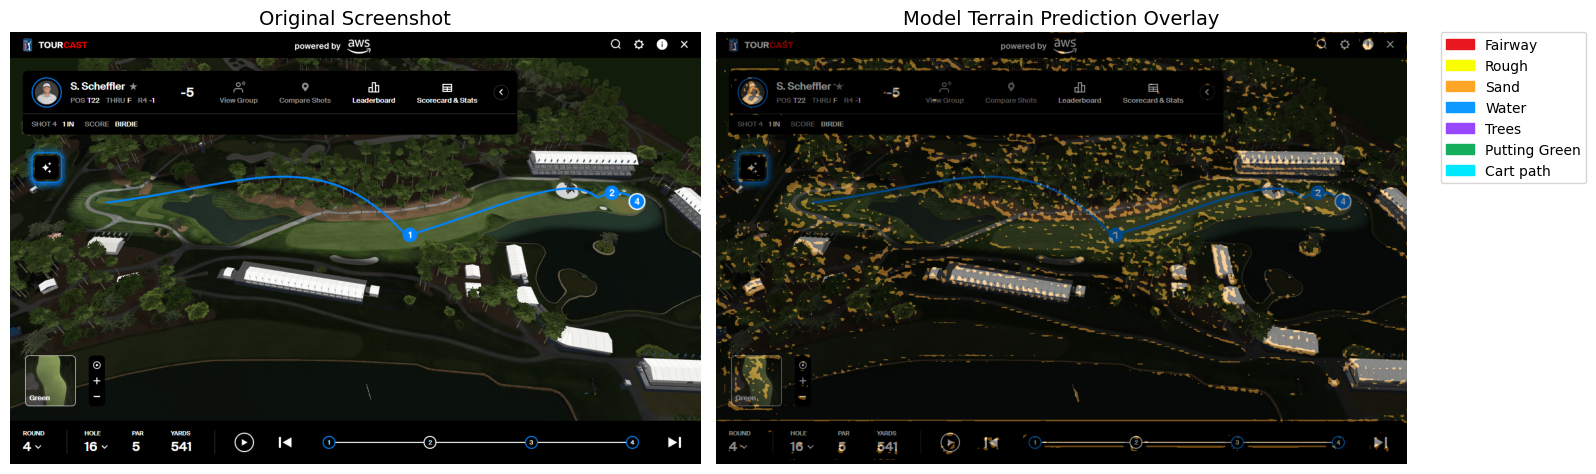

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Your exact defined color classes
COLOR_TO_CLASS = {
    # Color (R, G, B) : Class ID
    (231, 25, 31): 1,      # Red (Fairway)
    (250, 255, 0): 2,      # Yellow (Rough)
    (255, 166, 41): 3,     # Orange (Sand)
    (13, 153, 255): 4,     # Blue (Water)
    (151, 71, 255): 5,     # Purple (Trees)
    (20, 174, 92): 6,      # Green (Putting Green)
    (0, 232, 255): 7,      # Cyan (Cart path)
    (255, 0, 214): 8,      # Pink (UI, User Interface)
}

# Helper mapping for display names and legend generation
CLASS_NAMES = {
    1: "Fairway",
    2: "Rough",
    3: "Sand",
    4: "Water",
    5: "Trees",
    6: "Putting Green",
    7: "Cart path",
    8: "UI / User Interface"
}

def visualize_prediction(original_image_rgb, predicted_class_mask, alpha=0.5):
    h, w = predicted_class_mask.shape
    colored_mask = np.zeros((h, w, 3), dtype=np.uint8)

    # Invert dictionary to map Class ID -> RGB Color for fast coloring
    id_to_color = {class_id: rgb for rgb, class_id in COLOR_TO_CLASS.items()}

    # 2. Map each predicted class ID back to its specific RGB color
    for class_id, color in id_to_color.items():
        match = (predicted_class_mask == class_id)
        colored_mask[match] = color

    # 3. Blend the colored mask with the original image (ignoring background 0)
    mask_indices = (predicted_class_mask > 0)

    blended_image = original_image_rgb.copy()
    if np.any(mask_indices):
        blended_image[mask_indices] = cv2.addWeighted(
            original_image_rgb[mask_indices], 1.0 - alpha,
            colored_mask[mask_indices], alpha,
            0
        )

    # 4. Create Matplotlib Figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(original_image_rgb)
    axes[0].set_title("Original Screenshot", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(blended_image)
    axes[1].set_title("Model Terrain Prediction Overlay", fontsize=14)
    axes[1].axis("off")

    # 5. Build Legend based on your custom colors
    legend_patches = [
        mpatches.Patch(color=np.array(rgb)/255.0, label=CLASS_NAMES[cid])
        for rgb, cid in COLOR_TO_CLASS.items()
    ]
    axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# --- Example Execution ---
visualize_prediction(image_rgb, predicted_class_mask, alpha=0.45)

## Train SMP

### Dataset

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

# 1. Define your RGB to Class ID map (matching your notebook setup)
COLOR_TO_CLASS = {
    (231, 25, 31): 1,      # Fairway
    (250, 255, 0): 2,      # Rough
    (255, 166, 41): 3,     # Sand
    (13, 153, 255): 4,     # Water
    (151, 71, 255): 5,     # Trees
    (20, 174, 92): 6,      # Putting Green
    (0, 232, 255): 7,      # Cart path
    (255, 0, 214): 8,      # UI / User Interface
}

def rgb_to_class_mask(mask_rgb):
    """Converts an (H, W, 3) RGB mask image to an (H, W) single-channel class ID mask."""
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.int64) # Class 0 is Background by default

    for rgb, class_id in COLOR_TO_CLASS.items():
        # Match pixel values across RGB channels
        match = np.all(mask_rgb == rgb, axis=-1)
        class_mask[match] = class_id

    return class_mask

class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=(512, 512)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Read image and mask
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        # Resize both image and mask to target resolution
        img = cv2.resize(img, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_NEAREST)

        # Convert mask RGB to Class ID tensor (H, W)
        class_mask = rgb_to_class_mask(mask)
        mask_tensor = torch.tensor(class_mask, dtype=torch.long)

        # Normalize image to [0, 1] tensor (3, H, W)
        img_tensor = TF.to_tensor(img)
        img_tensor = TF.normalize(
            img_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        return img_tensor, mask_tensor

In [ ]:
import glob

seg_files = glob.glob("segmented_*")

for img_name in seg_files:
    img = cv2.imread(img_name)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define target HSV color range (e.g., green terrain)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])

    # Create binary mask (255 for target pixels, 0 for background)
    binary_mask = cv2.inRange(hsv, lower_green, upper_green)

    # Save mask image
    cv2.imwrite(f"mask_{img_name}", binary_mask)

In [ ]:
# Set up files like this:

# dataset/
# ├── images/
# │   ├── img1.jpg
# │   └── img2.jpg
# └── masks/
#     ├── img1.png  # Binary mask (0 = background, 255 = target)
#     └── img2.png

import os
import shutil
import glob

# Make folders
os.makedirs("dataset/images", exist_ok=True)
os.makedirs("dataset/masks", exist_ok=True)

# Move images and masks to folders
tournament_files = glob.glob("tournament_*")
print(tournament_files)
mask_files = glob.glob("mask_*")
print(mask_files)

for file in tournament_files:
    shutil.move(file, "dataset/images")

for file in mask_files:
    shutil.move(file, "dataset/masks")

['tournament_R2026011_player_46046_hole_16_round_4.png', 'tournament_R2021011_player_25804_hole_1_round_1.png', 'tournament_R2026011_player_46046_hole_17_round_4.png', 'tournament_R2025011_player_23108_hole_5_round_4.png']
['mask_segmented_tournament_R2026011_player_46046_hole_16_round_4.png', 'mask_segmented_tournament_R2021011_player_25804_hole_1_round_1.png', 'mask_segmented_tournament_R2026011_player_46046_hole_17_round_4.png', 'mask_segmented_tournament_R2025011_player_23108_hole_5_round_4.png']


In [ ]:
# List your dataset file paths
train_img_paths = glob.glob("dataset/images/tour*")

train_mask_paths = glob.glob("dataset/masks/mask*")

print(train_img_paths)
print(train_mask_paths)

['dataset/images/tournament_R2026011_player_46046_hole_16_round_4.png', 'dataset/images/tournament_R2021011_player_25804_hole_1_round_1.png', 'dataset/images/tournament_R2025011_player_23108_hole_5_round_4.png']
['dataset/masks/mask_segmented_tournament_R2026011_player_46046_hole_16_round_4.png', 'dataset/masks/mask_segmented_tournament_R2021011_player_25804_hole_1_round_1.png', 'dataset/masks/mask_segmented_tournament_R2025011_player_23108_hole_5_round_4.png']


### Model

In [ ]:
# Create PyTorch Dataset & DataLoader
train_dataset = SegmentationDataset(train_img_paths, train_mask_paths, img_size=(512, 512))
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

# Set hardware device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize SMP DeepLabV3+ Model
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=9, # 0=Background + 8 classes
).to(device)

criterion = smp.losses.DiceLoss(mode="multiclass")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 15

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device) # Shape: (B, 3, H, W)
        masks = masks.to(device)   # Shape: (B, H, W)

        optimizer.zero_grad()
        outputs = model(images)    # Output logits shape: (B, 9, H, W)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

# Save the trained model weights
torch.save(model.state_dict(), "smp_deeplabv3plus_best.pt")
print("Model training complete and weights saved!")

Epoch [1/15] Loss: 0.0919
Epoch [2/15] Loss: 0.0907
Epoch [3/15] Loss: 0.0884
Epoch [4/15] Loss: 0.0862
Epoch [5/15] Loss: 0.0839
Epoch [6/15] Loss: 0.0817
Epoch [7/15] Loss: 0.0795
Epoch [8/15] Loss: 0.0776
Epoch [9/15] Loss: 0.0756
Epoch [10/15] Loss: 0.0739
Epoch [11/15] Loss: 0.0721
Epoch [12/15] Loss: 0.0704
Epoch [13/15] Loss: 0.0689
Epoch [14/15] Loss: 0.0675
Epoch [15/15] Loss: 0.0660
Model training complete and weights saved!


### Results

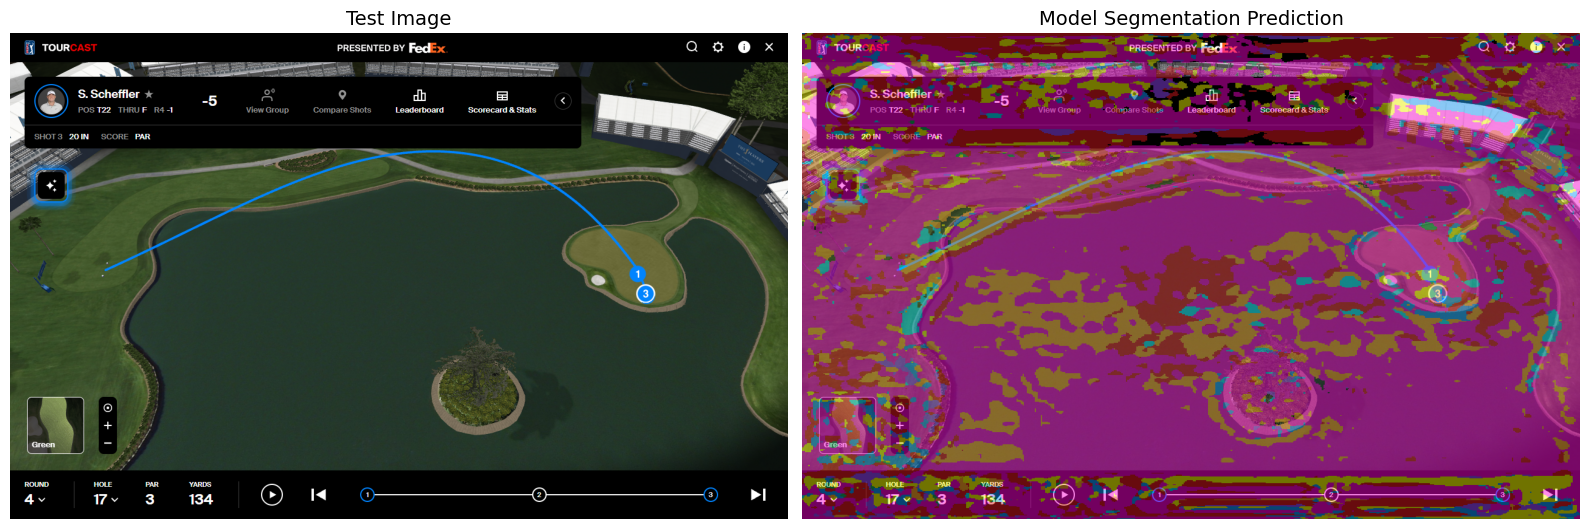

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def predict_and_visualize(test_image_path, model, device, img_size=(512, 512), alpha=0.45):
    # 1. Load test image
    img_bgr = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Store original resolution for plotting
    orig_h, orig_w, _ = img_rgb.shape

    # Preprocess test image
    img_resized = cv2.resize(img_rgb, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    input_tensor = TF.to_tensor(img_resized)
    input_tensor = TF.normalize(input_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    input_tensor = input_tensor.unsqueeze(0).to(device)  # Shape: (1, 3, H, W)

    # 2. Run inference
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor) # Output: (1, 9, H, W)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    # Resize predicted mask back to original image dimensions
    pred_mask = cv2.resize(pred_mask.astype(np.uint8), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # 3. Create colored overlay mask
    colored_mask = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
    for rgb, class_id in COLOR_TO_CLASS.items():
        match = (pred_mask == class_id)
        colored_mask[match] = rgb

    # Blend original image with predicted overlay
    mask_indices = (pred_mask > 0)
    blended = img_rgb.copy()
    if np.any(mask_indices):
        blended[mask_indices] = cv2.addWeighted(
            img_rgb[mask_indices], 1.0 - alpha,
            colored_mask[mask_indices], alpha, 0
        )

    # 4. Display results
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Test Image", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title("Model Segmentation Prediction", fontsize=14)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Run prediction on a test image
predict_and_visualize("tournament_R2026011_player_46046_hole_17_round_4.png", model, device)

## Train Without UI

In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

# 1. Define your RGB to Class ID map (matching your notebook setup)
COLOR_TO_CLASS = {
    (231, 25, 31): 1,      # Fairway
    (250, 255, 0): 2,      # Rough
    (255, 166, 41): 3,     # Sand
    (13, 153, 255): 4,     # Water
    (151, 71, 255): 5,     # Trees
    (20, 174, 92): 6,      # Putting Green
    (0, 232, 255): 7,      # Cart path
}

def rgb_to_class_mask(mask_rgb):
    """Converts an (H, W, 3) RGB mask image to an (H, W) single-channel class ID mask."""
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.int64) # Class 0 is Background by default

    for rgb, class_id in COLOR_TO_CLASS.items():
        # Match pixel values across RGB channels
        match = np.all(mask_rgb == rgb, axis=-1)
        class_mask[match] = class_id

    return class_mask

class SegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=(512, 512)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Read image and mask
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.mask_paths[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        # Resize both image and mask to target resolution
        img = cv2.resize(img, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_NEAREST)

        # Convert mask RGB to Class ID tensor (H, W)
        class_mask = rgb_to_class_mask(mask)
        mask_tensor = torch.tensor(class_mask, dtype=torch.long)

        # Normalize image to [0, 1] tensor (3, H, W)
        img_tensor = TF.to_tensor(img)
        img_tensor = TF.normalize(
            img_tensor,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        return img_tensor, mask_tensor

In [ ]:
import os
import shutil
import glob

# Make folders
os.makedirs("dataset_no_ui/images", exist_ok=True)
os.makedirs("dataset_no_ui/masks", exist_ok=True)

In [ ]:
import glob

seg_files = glob.glob("dataset_no_ui/segmented_*")
print(seg_files)
for img_name in seg_files:
    img = cv2.imread(img_name)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define target HSV color range (e.g., green terrain)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])

    # Create binary mask (255 for target pixels, 0 for background)
    binary_mask = cv2.inRange(hsv, lower_green, upper_green)

    # Save mask image
    cv2.imwrite(f"dataset_no_ui/masks/mask_{img_name.replace('dataset_no_ui/', '')}", binary_mask)

['dataset_no_ui/segmented_tournament_R2026011_player_46046_hole_16_round_4_no_ui.png', 'dataset_no_ui/segmented_tournament_R2021011_player_25804_hole_1_round_1_no_ui.png', 'dataset_no_ui/segmented_tournament_R2025011_player_23108_hole_5_round_4_no_ui.png', 'dataset_no_ui/segmented_tournament_R2026011_player_46046_hole_17_round_4_no_ui.png']


In [ ]:
# List your dataset file paths
train_img_paths = glob.glob("dataset_no_ui/images/tour*")

train_mask_paths = glob.glob("dataset_no_ui/masks/mask*")

print(train_img_paths)
print(train_mask_paths)

['dataset_no_ui/images/tournament_R2026011_player_46046_hole_16_round_4.png', 'dataset_no_ui/images/tournament_R2026011_player_46046_hole_17_round_4.png', 'dataset_no_ui/images/tournament_R2025011_player_23108_hole_5_round_4.png']
['dataset_no_ui/masks/mask_segmented_tournament_R2026011_player_46046_hole_16_round_4_no_ui.png', 'dataset_no_ui/masks/mask_segmented_tournament_R2026011_player_46046_hole_17_round_4_no_ui.png', 'dataset_no_ui/masks/mask_segmented_tournament_R2025011_player_23108_hole_5_round_4_no_ui.png']


In [ ]:
# Create PyTorch Dataset & DataLoader
train_dataset = SegmentationDataset(train_img_paths, train_mask_paths, img_size=(512, 512))
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

# Set hardware device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize SMP DeepLabV3+ Model
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=9, # 0=Background + 8 classes
).to(device)

criterion = smp.losses.DiceLoss(mode="multiclass")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 15

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device) # Shape: (B, 3, H, W)
        masks = masks.to(device)   # Shape: (B, H, W)

        optimizer.zero_grad()
        outputs = model(images)    # Output logits shape: (B, 9, H, W)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

# Save the trained model weights
torch.save(model.state_dict(), "smp_deeplabv3plus_best_no_ui.pt")
print("Model training complete and weights saved!")

Epoch [1/15] Loss: 0.0919
Epoch [2/15] Loss: 0.0907
Epoch [3/15] Loss: 0.0890
Epoch [4/15] Loss: 0.0870
Epoch [5/15] Loss: 0.0848
Epoch [6/15] Loss: 0.0826
Epoch [7/15] Loss: 0.0804
Epoch [8/15] Loss: 0.0784
Epoch [9/15] Loss: 0.0764
Epoch [10/15] Loss: 0.0747
Epoch [11/15] Loss: 0.0729
Epoch [12/15] Loss: 0.0712
Epoch [13/15] Loss: 0.0697
Epoch [14/15] Loss: 0.0682
Epoch [15/15] Loss: 0.0669
Model training complete and weights saved!


### Results

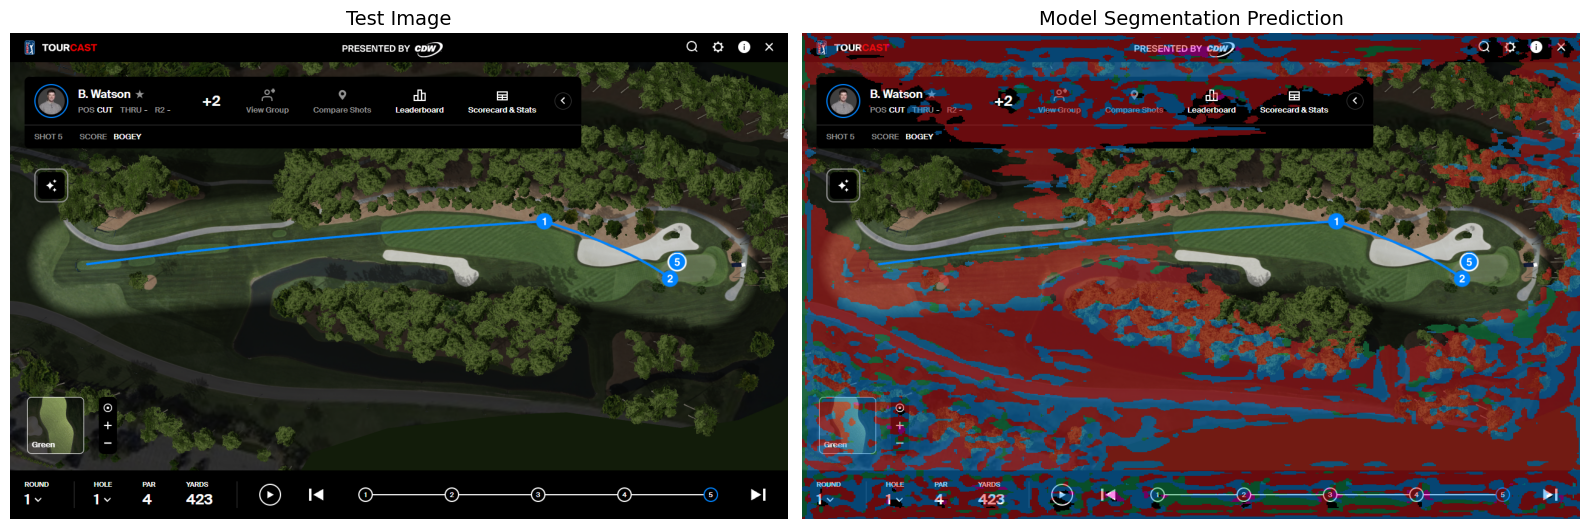

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def predict_and_visualize(test_image_path, model, device, img_size=(512, 512), alpha=0.45):
    # 1. Load test image
    img_bgr = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Store original resolution for plotting
    orig_h, orig_w, _ = img_rgb.shape

    # Preprocess test image
    img_resized = cv2.resize(img_rgb, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    input_tensor = TF.to_tensor(img_resized)
    input_tensor = TF.normalize(input_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    input_tensor = input_tensor.unsqueeze(0).to(device)  # Shape: (1, 3, H, W)

    # 2. Run inference
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor) # Output: (1, 9, H, W)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    # Resize predicted mask back to original image dimensions
    pred_mask = cv2.resize(pred_mask.astype(np.uint8), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # 3. Create colored overlay mask
    colored_mask = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
    for rgb, class_id in COLOR_TO_CLASS.items():
        match = (pred_mask == class_id)
        colored_mask[match] = rgb

    # Blend original image with predicted overlay
    mask_indices = (pred_mask > 0)
    blended = img_rgb.copy()
    if np.any(mask_indices):
        blended[mask_indices] = cv2.addWeighted(
            img_rgb[mask_indices], 1.0 - alpha,
            colored_mask[mask_indices], alpha, 0
        )

    # 4. Display results
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Test Image", fontsize=14)
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title("Model Segmentation Prediction", fontsize=14)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Run prediction on a test image
predict_and_visualize("dataset_no_ui/tournament_R2021011_player_25804_hole_1_round_1.png", model, device)